# 📏 Baseline Model

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/baseline-model/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/baseline-model/demo.ipynb)

**"We got 0.87 AUC." Compared to what?**

Every model review starts with a number and no context. A dumb baseline is the only thing that
turns a metric into a claim - and it is the step teams skip because it feels beneath them.

This notebook fits a ladder of deliberately stupid models, then asks whether the real model earns
the complexity it costs. On both bundled datasets, the answer is **no** - and that is the useful
result, not a bug in the demo.

### What this notebook covers
1. The ladder: five rungs from "ignore every feature" to "honest simple model"
2. Why accuracy on the majority-class rung equals the prevalence
3. The one-line rule that embarrasses pipelines
4. Classification: gradient boosting vs the ladder
5. Regression: the same test, and why R² has a baseline built into it
6. The verdict function - lift against the *strongest* baseline
7. Chart: the ladder, with the gap that actually matters
8. Try your own model

## Step 1 - The ladder

| Rung | Kind | What it exposes |
|---|---|---|
| majority class / mean | trivial | the metric's floor |
| stratified guess / median | trivial | whether the metric rewards guessing |
| best single rule | trivial | the model most likely to embarrass a pipeline |
| depth-2 tree | simple | how much signal sits in two or three cuts |
| logistic / linear | simple | what most projects should actually ship |

The split between *trivial* and *simple* matters for how you read the result. Losing to a trivial
rung means something is broken. Losing to a simple rung means you built the wrong thing.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple

import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

RANDOM_SEED = 42


@dataclass
class BaselineResult:
    name: str
    kind: str          # trivial | simple | candidate
    metrics: Dict[str, float]
    note: str = ""

    def primary(self, metric: str) -> float:
        return self.metrics.get(metric, float("nan"))


print("ladder ready")

ladder ready


## Step 2 - AUC on a constant predictor

The majority-class baseline has no ranking to score - it emits one constant prediction. Two
things are worth knowing before you decide what to put in that cell:

- With **constant scores and both classes present**, `roc_auc_score` does not raise. It returns
  `0.5`. That is correct and not a special case.
- With a **single class in `y_true`**, it returns `nan` and warns - the metric genuinely is
  undefined there.

So the guard is not crash protection, it is *reporting* protection: pass `y_prob=None` for the
rungs that have no ranking and record 0.5 explicitly, so the value in the table is a deliberate
statement ("worth chance") rather than an artifact of whatever the metric function happened to
do. Every cell stays populated, which matters because the majority row is the one a reader
compares everything against.

In [2]:
def _clf_metrics(y_true, y_pred, y_prob) -> Dict[str, float]:
    out = {"accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
           "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4)}
    # A rung with no ranking (constant prediction) is worth chance. Record 0.5
    # explicitly so the cell is a deliberate statement, not a metric artifact.
    if y_prob is None or len(np.unique(y_prob)) < 2:
        out["roc_auc"] = 0.5
    else:
        out["roc_auc"] = round(float(roc_auc_score(y_true, y_prob)), 4)
    return out


def _reg_metrics(y_true, y_pred) -> Dict[str, float]:
    return {"mae": round(float(mean_absolute_error(y_true, y_pred)), 4),
            "r2": round(float(r2_score(y_true, y_pred)), 4)}


# What sklearn actually does - verify rather than assume:
print("constant scores, both classes :", roc_auc_score([0, 1, 1, 0], [0.5] * 4), "(no error)")
with np.errstate(all="ignore"):
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        single = roc_auc_score([1, 1, 1, 1], [0.2, 0.5, 0.7, 0.9])
print("single class in y_true       :", single, "(undefined - warns)")
print("our guard records            :", _clf_metrics([0, 1, 1, 0], [1, 1, 1, 1], None))

constant scores, both classes : 0.5 (no error)
single class in y_true       : nan (undefined - warns)
our guard records            : {'accuracy': 0.5, 'f1': 0.6667, 'roc_auc': 0.5}


## Step 3 - The one-line rule

Brute force every feature against a 9-point quantile grid, both directions, keep the best F1 on
train, apply it to test. One feature. One threshold. No learning worth the name.

This is the rung that most often embarrasses a real pipeline, so it is worth having in the table
before someone asks for it in review.

In [3]:
def _best_single_rule(X_tr: pd.DataFrame, y_tr, X_te) -> Tuple[np.ndarray, str]:
    best = (-1.0, None, None, None)  # score, col, threshold, direction
    for col in X_tr.columns:
        vals = X_tr[col].to_numpy(dtype=float)
        for q in np.quantile(vals, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]):
            for direction in (1, -1):
                pred = ((vals > q) if direction == 1 else (vals <= q)).astype(int)
                s = f1_score(y_tr, pred, zero_division=0)
                if s > best[0]:
                    best = (s, col, float(q), direction)
    _, col, thresh, direction = best
    te = X_te[col].to_numpy(dtype=float)
    pred = ((te > thresh) if direction == 1 else (te <= thresh)).astype(int)
    return pred, f"{col} {'>' if direction == 1 else '<='} {thresh:.3g}"


from sklearn.datasets import load_breast_cancer

d = load_breast_cancer(as_frame=True)
X, y = d.data, d.target.to_numpy()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED,
                                          stratify=y)
pred, rule = _best_single_rule(X_tr, y_tr, X_te)
print(f"best single rule found: if {rule}")
print(f"  -> test F1 {f1_score(y_te, pred):.4f}, accuracy {accuracy_score(y_te, pred):.4f}")
print(f"     out of 30 features and {len(X_tr)} training rows.")

best single rule found: if worst perimeter <= 115
  -> test F1 0.9412, accuracy 0.9231
     out of 30 features and 426 training rows.


## Step 4 - Classification: the full ladder

Gradient boosting against all five rungs. Watch the `accuracy` column on the majority row and
compare it to `prevalence`.

In [4]:
def run_classification(X, y, candidate=None, candidate_name="candidate", test_size=0.25):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size,
                                              random_state=RANDOM_SEED, stratify=y)
    out, major = [], int(pd.Series(y_tr).mode()[0])

    dm = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
    out.append(BaselineResult("majority class", "trivial",
                             _clf_metrics(y_te, dm.predict(X_te), None),
                             f"always predicts {major}; accuracy = majority share"))

    ds = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED).fit(X_tr, y_tr)
    out.append(BaselineResult("stratified guess", "trivial",
                             _clf_metrics(y_te, ds.predict(X_te), ds.predict_proba(X_te)[:, 1]),
                             "random, class ratio preserved"))

    p, rule = _best_single_rule(X_tr, y_tr, X_te)
    out.append(BaselineResult("best single rule", "trivial",
                             _clf_metrics(y_te, p, p.astype(float)), f"if {rule}"))

    t = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_SEED).fit(X_tr, y_tr)
    out.append(BaselineResult("depth-2 tree", "simple",
                             _clf_metrics(y_te, t.predict(X_te), t.predict_proba(X_te)[:, 1]),
                             "at most 3 splits"))

    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)
    out.append(BaselineResult("logistic regression", "simple",
                             _clf_metrics(y_te, lr.predict(X_te), lr.predict_proba(X_te)[:, 1]),
                             "linear, scaled features"))

    if candidate is not None:
        candidate.fit(X_tr, y_tr)
        prob = candidate.predict_proba(X_te)[:, 1] if hasattr(candidate, "predict_proba") else None
        out.append(BaselineResult(candidate_name, "candidate",
                                  _clf_metrics(y_te, candidate.predict(X_te), prob),
                                  "the model under review"))
    for r in out:
        r.metrics["prevalence"] = round(float(np.mean(y_te)), 4)
    return out


def to_frame(results, order=None):
    rows = []
    for r in results:
        row = {"model": r.name, "kind": r.kind}
        row.update(r.metrics)
        row["note"] = r.note
        rows.append(row)
    df = pd.DataFrame(rows)
    if order:
        df = df[["model", "kind"] + [c for c in order if c in df.columns] + ["note"]]
    return df


clf_results = run_classification(X, y, GradientBoostingClassifier(random_state=RANDOM_SEED),
                                 "gradient boosting")
print(to_frame(clf_results, ["roc_auc", "f1", "accuracy", "prevalence"]).to_string(index=False))

              model      kind  roc_auc     f1  accuracy  prevalence                                         note
     majority class   trivial   0.5000 0.7725    0.6294      0.6294 always predicts 1; accuracy = majority share
   stratified guess   trivial   0.4770 0.6230    0.5175      0.6294                random, class ratio preserved
   best single rule   trivial   0.9040 0.9412    0.9231      0.6294                    if worst perimeter <= 115
       depth-2 tree    simple   0.9382 0.9249    0.9091      0.6294                             at most 3 splits
logistic regression    simple   0.9977 0.9889    0.9860      0.6294                      linear, scaled features
  gradient boosting candidate   0.9925 0.9674    0.9580      0.6294                       the model under review


Two things in that table are worth stopping on.

**The majority row scores 0.77 F1 and 0.63 accuracy while learning nothing.** Its accuracy is the
prevalence, exactly. Anyone reporting "63% accurate" on this data has reported the class balance.

**The one-line rule reaches 0.94 F1.** A single threshold on a single feature. If a model review
does not include this row, "our model gets 0.96" sounds like an achievement instead of a
0.02 improvement over one `if` statement.

## Step 5 - Regression, where the baseline is already inside the metric

R² is *defined* as improvement over predicting the mean, so the mean rung should land near zero.
It lands slightly **negative** - because the mean is computed on train and scored on test, and
those two means are not identical. A small thing, but it is the difference between understanding
the metric and reciting it.

In [5]:
def run_regression(X, y, candidate=None, candidate_name="candidate", test_size=0.25):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size,
                                              random_state=RANDOM_SEED)
    out = []
    dmean = DummyRegressor(strategy="mean").fit(X_tr, y_tr)
    out.append(BaselineResult("predict the mean", "trivial", _reg_metrics(y_te, dmean.predict(X_te)),
                              "what R2 is defined against; slightly negative out-of-sample"))
    dmed = DummyRegressor(strategy="median").fit(X_tr, y_tr)
    out.append(BaselineResult("predict the median", "trivial", _reg_metrics(y_te, dmed.predict(X_te)),
                              "beats the mean on MAE when the target is skewed"))
    t = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_SEED).fit(X_tr, y_tr)
    out.append(BaselineResult("depth-2 tree", "simple", _reg_metrics(y_te, t.predict(X_te)),
                              "at most 3 splits"))
    lin = make_pipeline(StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
    out.append(BaselineResult("linear regression", "simple", _reg_metrics(y_te, lin.predict(X_te)),
                              "linear, scaled features"))
    if candidate is not None:
        candidate.fit(X_tr, y_tr)
        out.append(BaselineResult(candidate_name, "candidate",
                                  _reg_metrics(y_te, candidate.predict(X_te)),
                                  "the model under review"))
    return out


from sklearn.datasets import load_diabetes

dd = load_diabetes(as_frame=True)
Xr, yr = dd.data, dd.target.to_numpy()
reg_results = run_regression(Xr, yr, GradientBoostingRegressor(random_state=RANDOM_SEED),
                             "gradient boosting")
print(to_frame(reg_results, ["r2", "mae"]).to_string(index=False))

             model      kind      r2     mae                                                        note
  predict the mean   trivial -0.0140 65.5274 what R2 is defined against; slightly negative out-of-sample
predict the median   trivial -0.0023 63.9550             beats the mean on MAE when the target is skewed
      depth-2 tree    simple  0.3588 47.3338                                            at most 3 splits
 linear regression    simple  0.4849 41.5485                                     linear, scaled features
 gradient boosting candidate  0.4240 44.2600                                      the model under review


## Step 6 - The verdict

Lift is measured against the **strongest** baseline, not the weakest. Beating "predict the mean"
is not an achievement, and a verdict function that lets you claim it is worse than no verdict at
all.

In [6]:
MIN_LIFT = 0.02


def verdict(results, metric="roc_auc", min_lift=MIN_LIFT):
    cand = next((r for r in results if r.kind == "candidate"), None)
    baselines = [r for r in results if r.kind != "candidate"]
    higher_is_better = metric != "mae"
    key = (lambda r: r.primary(metric)) if higher_is_better else (lambda r: -r.primary(metric))
    best_base = max(baselines, key=key)
    best_trivial = max([r for r in baselines if r.kind == "trivial"], key=key)
    cand_score = cand.primary(metric)
    lift = (cand_score - best_base.primary(metric)) if higher_is_better else \
           (best_base.primary(metric) - cand_score)
    ok = bool(lift >= min_lift)
    return {"metric": metric, "candidate": cand.name, "candidate_score": cand_score,
            "best_baseline": best_base.name, "best_baseline_score": best_base.primary(metric),
            "best_trivial": best_trivial.name, "best_trivial_score": best_trivial.primary(metric),
            "lift": round(float(lift), 4), "ok": ok, "min_lift": min_lift}


for label, res, metric in (("CLASSIFICATION", clf_results, "roc_auc"),
                           ("REGRESSION", reg_results, "r2")):
    v = verdict(res, metric)
    print(f"{label} (deciding on {metric})")
    print(f"  strongest baseline : {v['best_baseline']:<22} {v['best_baseline_score']}")
    print(f"  strongest TRIVIAL  : {v['best_trivial']:<22} {v['best_trivial_score']}")
    print(f"  candidate          : {v['candidate']:<22} {v['candidate_score']}")
    print(f"  lift               : {v['lift']:+.4f}  ->  "
          f"{'WORTH IT' if v['ok'] else 'NOT WORTH IT (below the ' + str(v['min_lift']) + ' bar)'}\n")

CLASSIFICATION (deciding on roc_auc)
  strongest baseline : logistic regression    0.9977
  strongest TRIVIAL  : best single rule       0.904
  candidate          : gradient boosting      0.9925
  lift               : -0.0052  ->  NOT WORTH IT (below the 0.02 bar)

REGRESSION (deciding on r2)
  strongest baseline : linear regression      0.4849
  strongest TRIVIAL  : predict the median     -0.0023
  candidate          : gradient boosting      0.424
  lift               : -0.0609  ->  NOT WORTH IT (below the 0.02 bar)



**Gradient boosting loses on both datasets.** Not by much - but it loses, to a scaled linear
model that trains in milliseconds and can be read off as coefficients.

This is the outcome the tool exists to surface. Without the ladder, both of these ship as
"0.99 AUC" and "0.42 R²" and nobody asks the question.

## Step 7 - The picture

The bar to clear is the tallest non-candidate bar, marked with the dashed line. Distance from
zero is not the achievement.

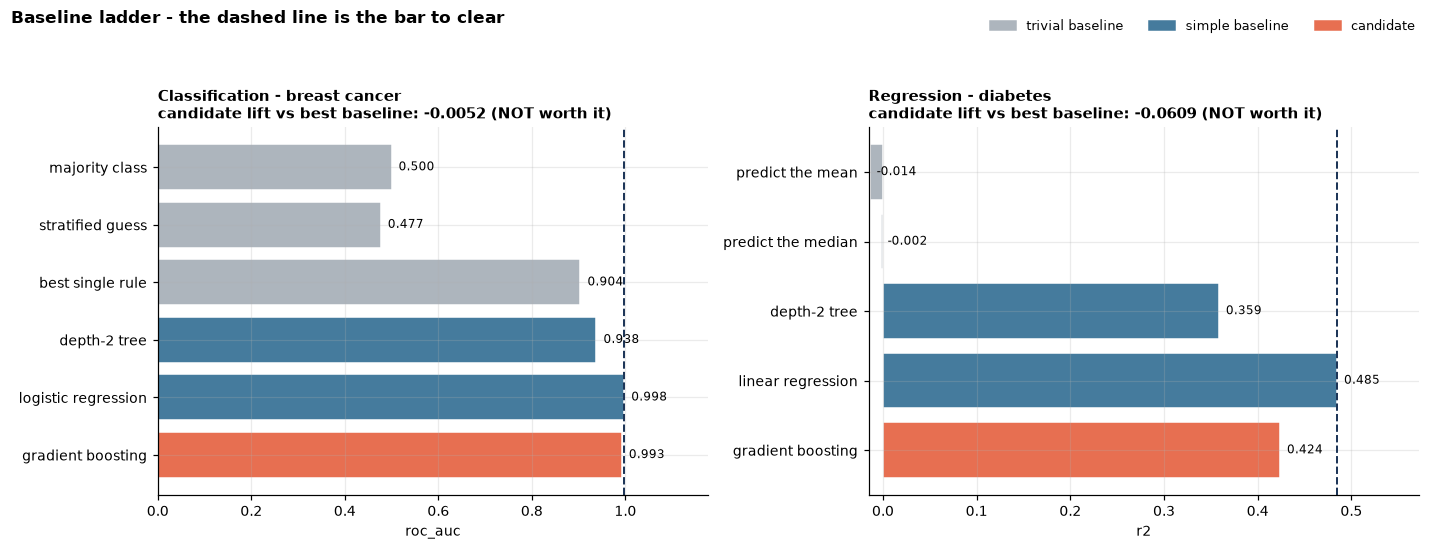

In [7]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

KIND_COLOR = {"trivial": "#adb5bd", "simple": "#457b9d", "candidate": "#e76f51"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, res, metric, title in ((axes[0], clf_results, "roc_auc", "Classification - breast cancer"),
                               (axes[1], reg_results, "r2", "Regression - diabetes")):
    names = [r.name for r in res]
    vals = [r.primary(metric) for r in res]
    colors = [KIND_COLOR[r.kind] for r in res]
    bars = ax.barh(names, vals, color=colors, edgecolor="white")
    ax.invert_yaxis()
    best_base = max([r for r in res if r.kind != "candidate"], key=lambda r: r.primary(metric))
    ax.axvline(best_base.primary(metric), ls="--", lw=1.3, color="#1d3557")
    v = verdict(res, metric)
    ax.set_xlabel(metric)
    ax.set_title(f"{title}\ncandidate lift vs best baseline: {v['lift']:+.4f} "
                 f"({'worth it' if v['ok'] else 'NOT worth it'})",
                 loc="left", fontweight="bold", fontsize=9.5)
    for b, val in zip(bars, vals):
        ax.text(val + (max(vals) * 0.015), b.get_y() + b.get_height() / 2, f"{val:.3f}",
                va="center", fontsize=8)
    ax.set_xlim(min(0, min(vals) * 1.1), max(vals) * 1.18)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in KIND_COLOR.values()]
labels = [f"{k} baseline" if k != "candidate" else "candidate" for k in KIND_COLOR]
fig.legend(handles, labels, frameon=False, fontsize=8.5, ncol=3, loc="upper right",
           bbox_to_anchor=(0.995, 1.035))
fig.suptitle("Baseline ladder - the dashed line is the bar to clear",
             fontsize=11, fontweight="bold", x=0.005, ha="left", y=1.03)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("baseline_ladder.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| | Classification (AUC) | Regression (R²) |
|---|---|---|
| Best trivial rung | best single rule — **0.904** | predict the median — **-0.002** |
| Best baseline overall | logistic regression — **0.998** | linear regression — **0.485** |
| Gradient boosting | **0.993** | **0.424** |
| Lift vs best baseline | **-0.005** | **-0.061** |
| Verdict | not worth it | not worth it |

**The takeaway:** on both datasets the complex model is *behind* a scaled linear model. The
number that would have shipped ("0.99 AUC") is real and also meaningless on its own, because a
single `if` statement gets 0.90 and the linear model gets more than the booster.

Run the ladder before the model review, not after someone asks.

## Try your own model

In [8]:
# --- swap in your candidate ----------------------------------------------
# from sklearn.svm import SVC
# my_results = run_classification(X, y, SVC(probability=True, random_state=RANDOM_SEED), "SVC")
# print(to_frame(my_results, ["roc_auc", "f1", "accuracy"]).to_string(index=False))
# print(verdict(my_results, "roc_auc", min_lift=0.02))
#
# --- or your own data ----------------------------------------------------
# df = pd.read_csv("my_data.csv")
# y_mine = df.pop("target").to_numpy()
# my_results = run_classification(df, y_mine, GradientBoostingClassifier(), "mine")
# print(verdict(my_results, "roc_auc"))

from sklearn.linear_model import RidgeClassifier

demo = run_classification(X, y, RidgeClassifier(random_state=RANDOM_SEED), "ridge classifier")
v = verdict(demo, "f1", min_lift=0.02)
print(f"ridge classifier: f1 {v['candidate_score']} vs best baseline "
      f"'{v['best_baseline']}' {v['best_baseline_score']} -> lift {v['lift']:+.4f} "
      f"({'worth it' if v['ok'] else 'not worth it'})")

ridge classifier: f1 0.9626 vs best baseline 'logistic regression' 0.9889 -> lift -0.0263 (not worth it)


---

**Day 127** of the daily FDE build - **ML Engineering Toolkit** line.

Companions: **Day 122** [`threshold-explorer`](../threshold-explorer) (once you've earned a model,
pick its cutoff), **Day 76** [`train-eval-harness`](../train-eval-harness),
**Day 78** [`model-card-gen`](../model-card-gen) (the ladder belongs in the model card).

```bash
pip install -r requirements.txt
streamlit run app.py     # pick a task + candidate, get a verdict
python baseline.py       # CLI, both ladders
```

← [Back to the portfolio](https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/baseline-model)